# 03. Statistical analysis

**Owner:** Anibal  \
**Inputs:** see `config/paths.yml`  \
**Outputs:** figures to `reports/figures/`, data to `data/processed/`

## Purpose

Question A: what is the relationship between demographic aging, rural depopulation and fire incidence in agricultural areas?


## Setup

Every chapter starts with this identical cell. Do not add ad-hoc paths below it — put new paths in `config/paths.yml`.

In [1]:
import importlib
import sys
from pathlib import Path
import warnings

# Make the src-layout package importable when the notebook kernel is not installed with -e .
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "pyproject.toml").is_file():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from wildfires.config import CONVENTIONS, MIN_FIRE_HA, PATHS, STUDY_YEARS
from wildfires.viz import apply_theme, save_figure

apply_theme()
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

import statsmodels.api as sm
import wildfires.io as wildfires_io

wildfires_io = importlib.reload(wildfires_io)
load_icnf = wildfires_io.load_icnf
load_ine_population_age_all = wildfires_io.load_ine_population_age_all
load_ine_population_all = wildfires_io.load_ine_population_all
load_panel = wildfires_io.load_panel
from wildfires.features import add_lags, cause_shares, log1p_safe

## Load panel

### INE (population dataset)

In [2]:
population_age_data = load_ine_population_age_all(
    years=range(STUDY_YEARS[0], STUDY_YEARS[1] + 1)
)

c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: II_01_01!$A:$O.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: II_01_06c!$A:$P.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'II_01 02'!$A:$S.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'II_01 04'!$A:$J.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workb

In [3]:
population_age_data

,municipality,dtcc,Total,0 a 14 anos,15 a 24 anos,ine_year,geo_level,25-64 anos,65 e mais anos__Total,75 e mais anos
0,Arcos de Valdevez,1601,20926,1994,1944,2019,municipality,10181,6807,4140
1,Caminha,1602,15877,1743,1546,2019,municipality,8478,4110,2120
2,Melgaço,1603,8093,646,661,2019,municipality,3845,2941,1867
3,Monção,1604,17869,1711,1535,2019,municipality,9348,5275,3009
4,Paredes de Coura,1605,8535,953,775,2019,municipality,4426,2381,1387
...,...,...,...,...,...,...,...,...,...,...
1843,Ribeira Brava,3107,13322,1550,1633,2024,municipality,7299,2840,1310
1844,Santa Cruz,3108,44816,6170,5233,2024,municipality,26252,7161,2899
1845,Santana,3109,6516,622,622,2024,municipality,3356,1916,988
1846,São Vicente,3110,5123,505,522,2024,municipality,2693,1403,670


### INCF (wildfire dataset)

In [17]:
wildfire_data = load_icnf(level="concelho")
wildfire_data

,year,DTCC,Distrito,Concelho,Região NUTS III (2024),Num_IncendiosRurais,AreaArdPov_NoConcelho,AreaArdMato_NoConcelho,AreaArdAgric_NoConcelho,AreaArdTotal_NoConcelho,AreaArdPov_IncendioInicioConc,AreaArdMato_IncendioInicioConc,AreaArdAgric_IncendioInicioConc,AreaArdTotal_IncendioInicioConc,NIncRur_0_1ha,NIncRur_1_10ha,NIncRur_10_20ha,NIncRur_20_50ha,NIncRur_50_100ha,NIncRur_100_500ha,NIncRur_500_1000ha,NIncRur_1000_n_ha,NInc_Natural,NInc_Negligente,NInc_Intencionais,NInc_Reacendimentos,NInc_Desconhecida,NInc_NaoInvestigados,Ninc_Sup24h,dtcc
0,2001,101,Aveiro,Águeda,Região de Aveiro,84,NaN,NaN,NaN,NaN,7.8582,2.2464,0.000,10.1046,83,1,0,0,0,0,0,0,0,1,0,3,0,80,0,0101
1,2001,102,Aveiro,Albergaria-a-Velha,Região de Aveiro,87,NaN,NaN,NaN,NaN,55.8702,7.8302,0.000,63.7004,74,11,2,0,0,0,0,0,0,0,2,6,0,79,0,0102
2,2001,103,Aveiro,Anadia,Região de Aveiro,65,NaN,NaN,NaN,NaN,10.1313,1.9012,0.035,12.0675,62,3,0,0,0,0,0,0,0,1,5,2,0,57,0,0103
3,2001,104,Aveiro,Arouca,Área Metropolitana do Porto,253,NaN,NaN,NaN,NaN,564.0250,374.1800,0.220,938.4250,203,38,3,2,4,3,0,0,0,3,1,0,0,249,1,0104
4,2001,105,Aveiro,Aveiro,Região de Aveiro,39,NaN,NaN,NaN,NaN,0.0710,1.4612,0.570,2.1022,39,0,0,0,0,0,0,0,0,0,0,2,0,37,0,0105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6916,2025,1820,Viseu,Tarouca,Douro,10,192.235486,484.834016,47.905362,724.974864,NaN,NaN,NaN,NaN,9,0,0,0,0,1,0,0,0,8,2,0,0,0,1,1820
6917,2025,1821,Viseu,Tondela,Viseu Dão Lafões,26,36.931977,2.725237,3.861942,43.519156,NaN,NaN,NaN,NaN,22,3,0,1,0,0,0,0,0,16,9,1,0,0,0,1821
6918,2025,1822,Viseu,Vila Nova de Paiva,Viseu Dão Lafões,12,94.319453,14.904818,0.781380,110.005651,NaN,NaN,NaN,NaN,10,2,0,0,0,0,0,0,1,10,1,0,0,0,0,1822
6919,2025,1823,Viseu,Viseu,Viseu Dão Lafões,77,233.791717,58.792272,14.157818,306.741808,NaN,NaN,NaN,NaN,70,4,1,0,1,1,0,0,0,33,26,4,14,0,1,1823


## Exploratory visualisations

### Sernancelhe

In [9]:
pop_sernancelhe = population_age_data.loc[
    population_age_data["municipality"] == "Sernancelhe",
    ["0 a 14 anos", "15 a 24 anos", "25-64 anos", "65 e mais anos__Total", "75 e mais anos", "ine_year"]
]

In [10]:
pop_sernancelhe

,0 a 14 anos,15 a 24 anos,25-64 anos,65 e mais anos__Total,75 e mais anos,ine_year
71,487,580,2912,1417,819,2019
379,472,549,2927,1427,824,2020
687,520,532,2818,1819,973,2021
995,500,531,2851,1853,972,2022
1303,504,522,2895,1872,978,2023
1611,499,509,2902,1908,985,2024


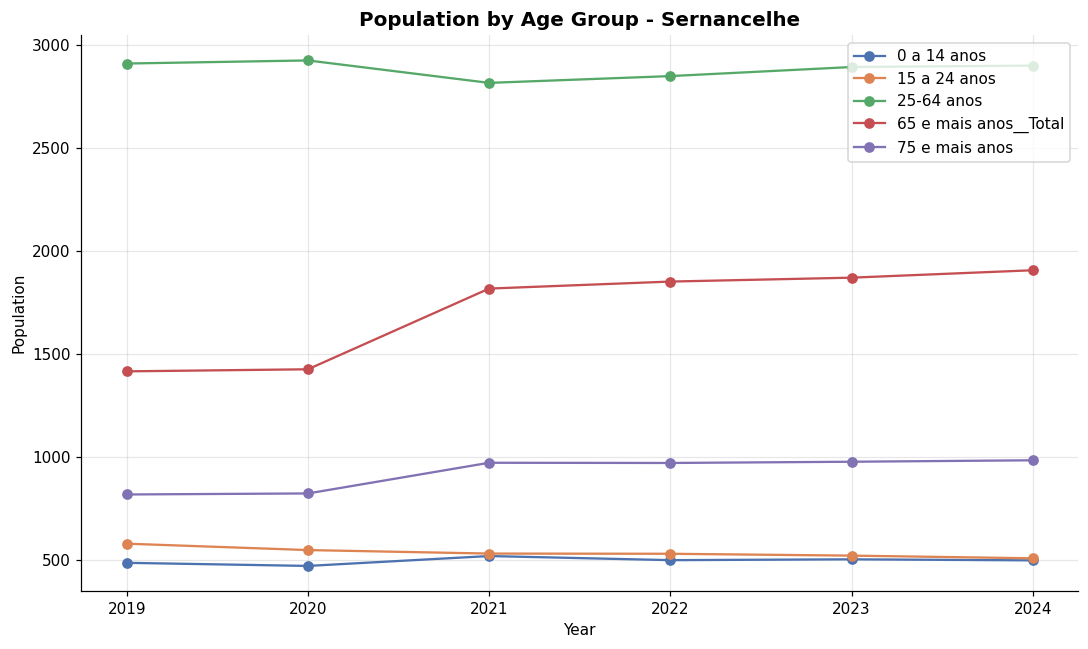

In [40]:
import matplotlib.pyplot as plt

# Set year as index (optional)
df = pop_sernancelhe.set_index("ine_year")

plt.figure(figsize=(10, 6))

for col in ["0 a 14 anos", "15 a 24 anos", "25-64 anos", "65 e mais anos__Total", "75 e mais anos"]:
    plt.plot(df.index, df[col], marker="o", label=col)

plt.title("Population by Age Group - Sernancelhe")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
wildfire_sernancelhe = wildfire_data.loc[
    wildfire_data["year"].between(2001, 2024) &
    (wildfire_data["Concelho"] == "Sernancelhe"),
    ["year", "Num_IncendiosRurais"]
]

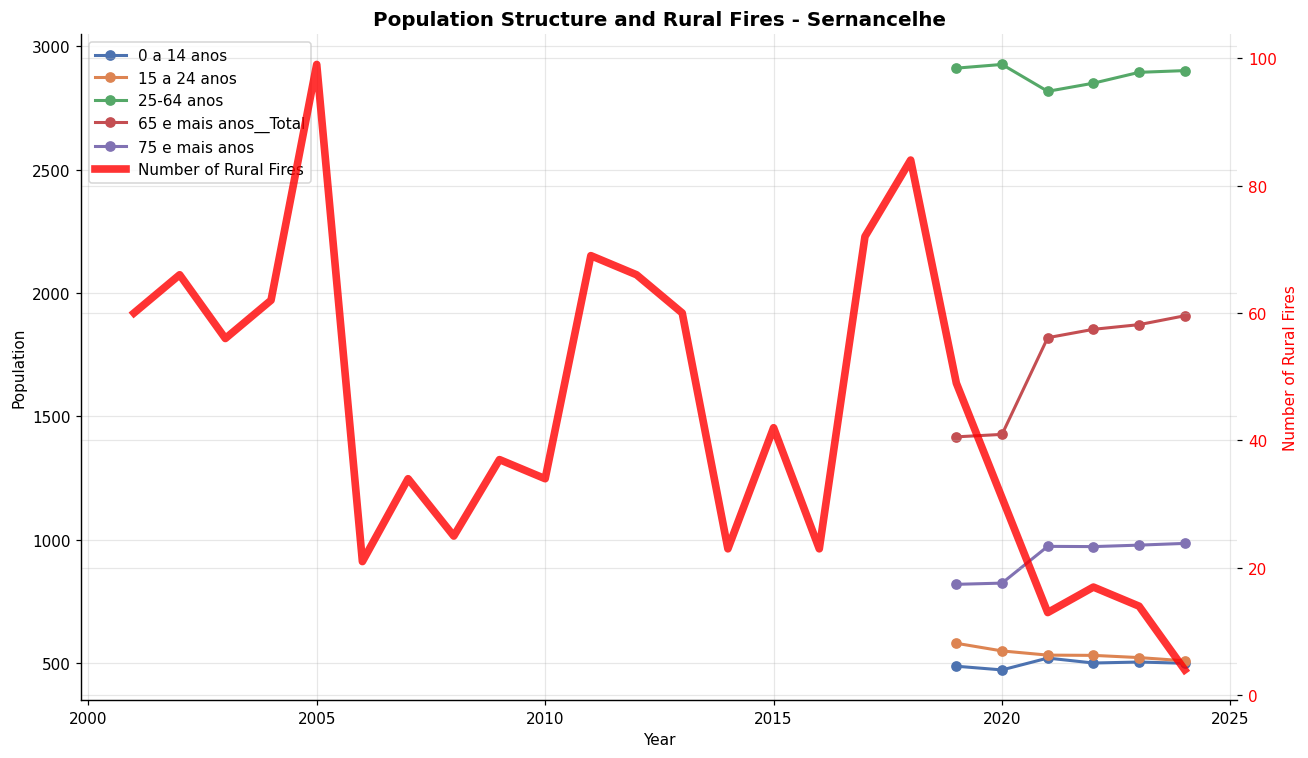

In [39]:
import matplotlib.pyplot as plt

# Population data
pop_df = pop_sernancelhe.set_index("ine_year")

# Fire data
fire_df = wildfire_sernancelhe.set_index("year")

fig, ax1 = plt.subplots(figsize=(12, 7))

# Population lines (left axis)
population_cols = [
    "0 a 14 anos",
    "15 a 24 anos",
    "25-64 anos",
    "65 e mais anos__Total",  # adjust if your actual column name differs
    "75 e mais anos"
]

for col in population_cols:
    ax1.plot(
        pop_df.index,
        pop_df[col],
        marker="o",
        linewidth=2,
        label=col
    )

ax1.set_xlabel("Year")
ax1.set_ylabel("Population")
ax1.grid(True, alpha=0.3)

# Fire axis (right)
ax2 = ax1.twinx()

ax2.plot(
    fire_df.index,
    fire_df["Num_IncendiosRurais"],
    color="red",
    linewidth=5,
    alpha=0.8,
    label="Number of Rural Fires"
)

ax2.set_ylabel("Number of Rural Fires", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Merge legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.title("Population Structure and Rural Fires - Sernancelhe")
plt.tight_layout()
plt.show()

### Covilhã

In [ ]:
population_cols = [
    "0 a 14 anos",
    "15 a 24 anos",
    "25-64 anos",
    "65 e mais anos__Total",
    "75 e mais anos",
]

pop_covilha = population_age_data.loc[
    population_age_data["municipality"] == "Covilhã",
    population_cols + ["ine_year"],
]
wildfire_covilha = wildfire_data.loc[
    wildfire_data["year"].between(2001, 2024)
    & (wildfire_data["Concelho"] == "Covilhã"),
    ["year", "Num_IncendiosRurais"],
]

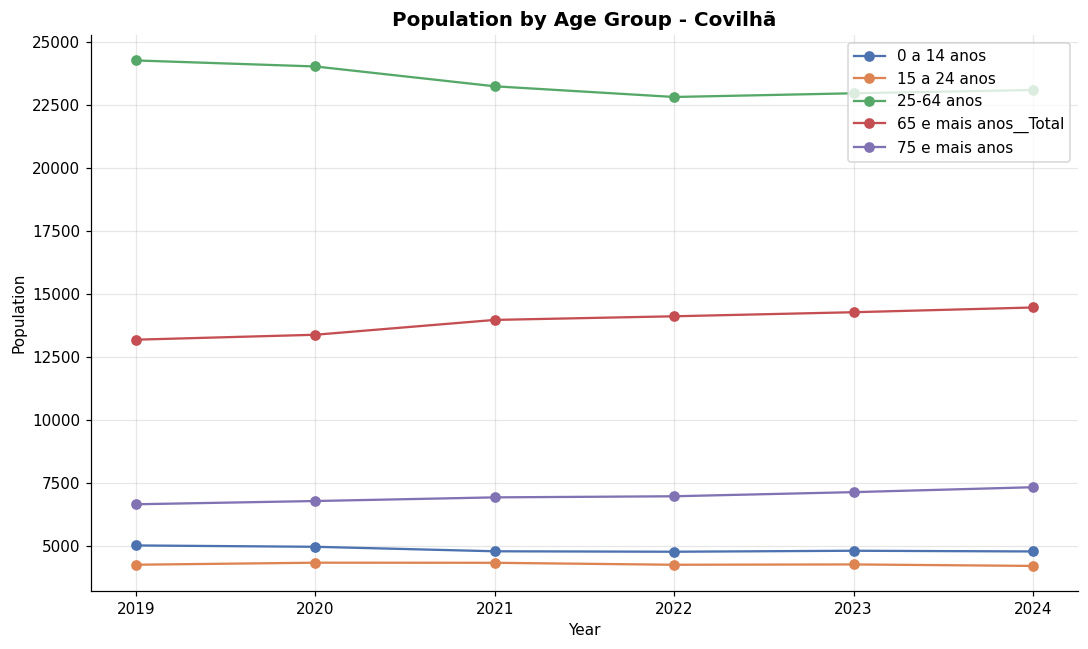

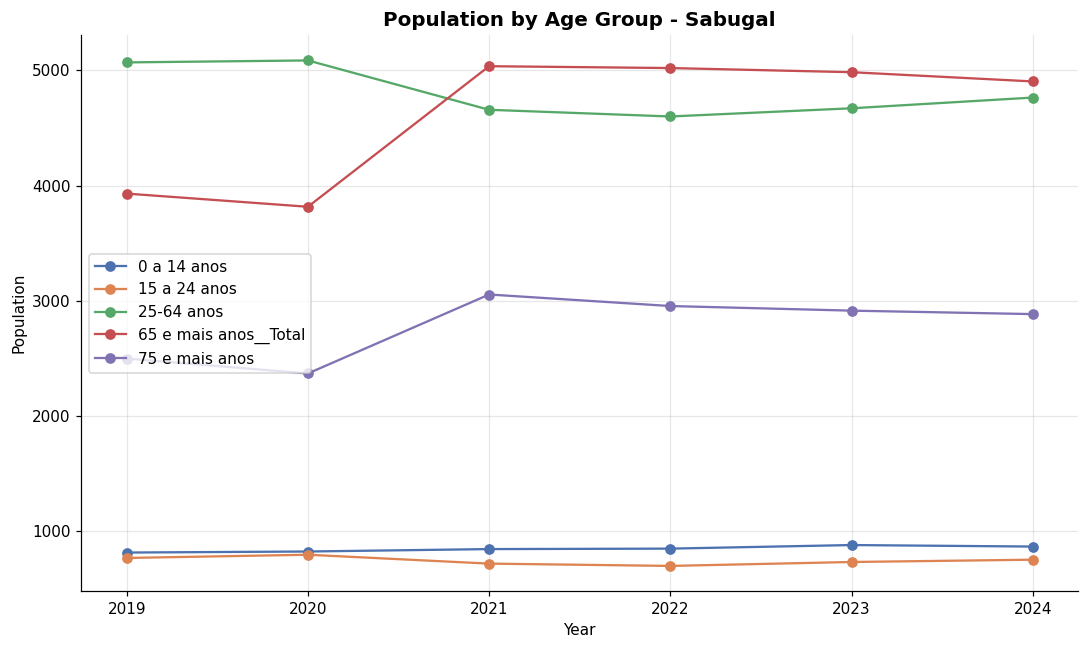

In [ ]:
df = pop_covilha.set_index("ine_year")

plt.figure(figsize=(10, 6))
for col in population_cols:
    plt.plot(df.index, df[col], marker="o", label=col)

plt.title("Population by Age Group - Covilhã")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

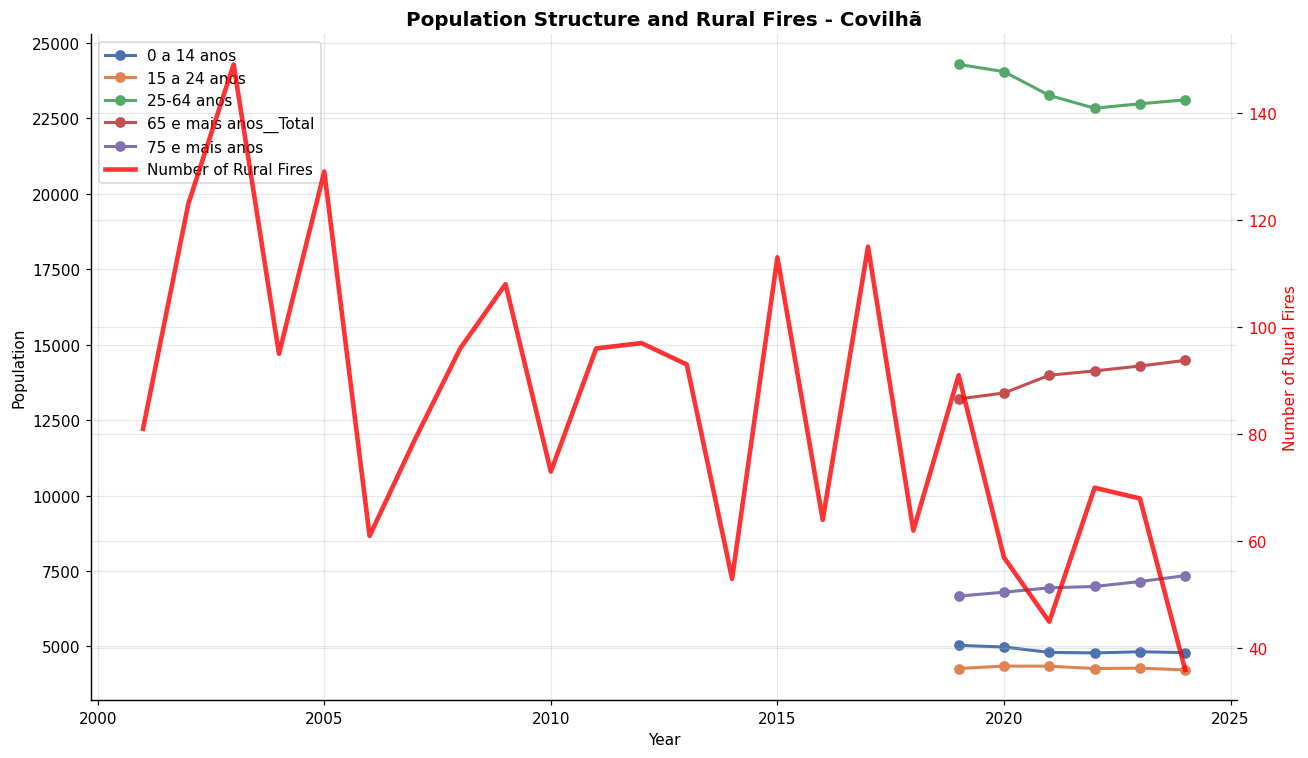

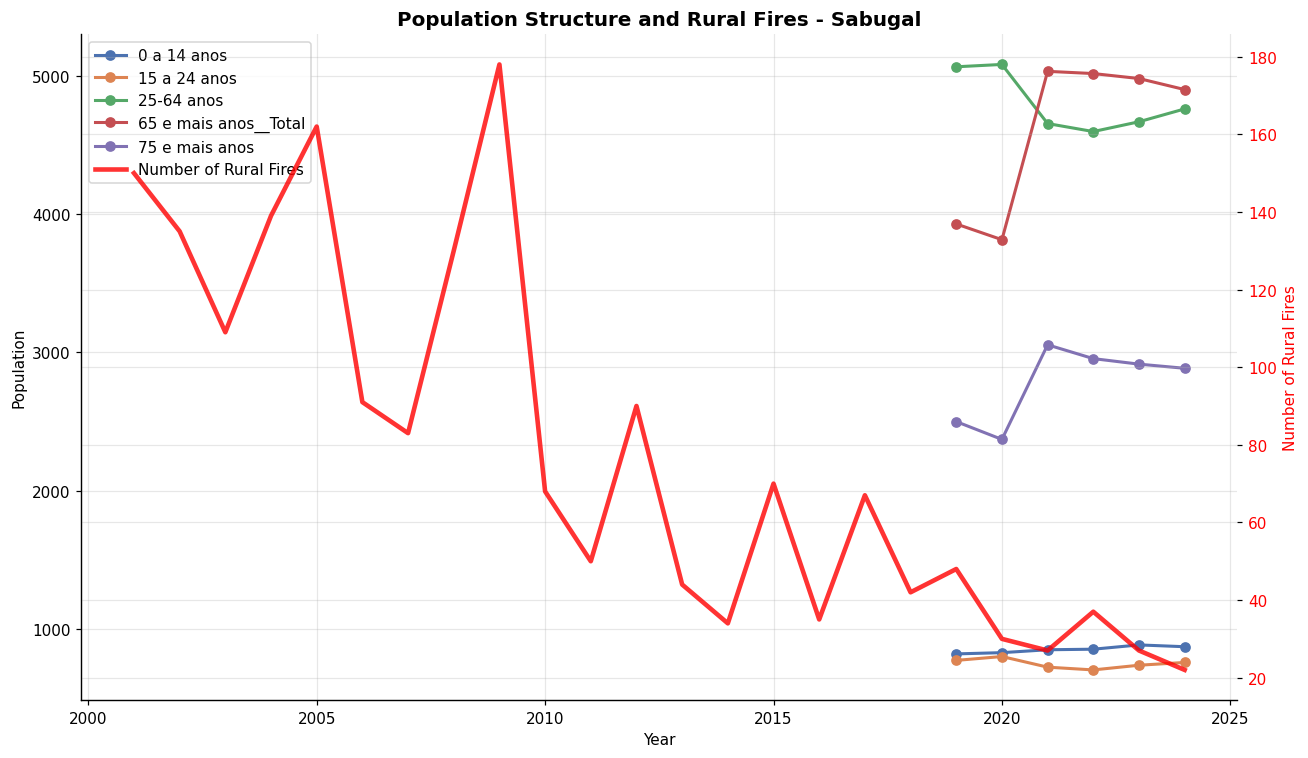

In [ ]:
pop_df = pop_covilha.set_index("ine_year")
fire_df = wildfire_covilha.set_index("year")

fig, ax1 = plt.subplots(figsize=(12, 7))
for col in population_cols:
    ax1.plot(
        pop_df.index,
        pop_df[col],
        marker="o",
        linewidth=2,
        label=col,
    )

ax1.set_xlabel("Year")
ax1.set_ylabel("Population")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    fire_df.index,
    fire_df["Num_IncendiosRurais"],
    color="red",
    linewidth=3,
    alpha=0.8,
    label="Number of Rural Fires",
)
ax2.set_ylabel("Number of Rural Fires", color="red")
ax2.tick_params(axis="y", labelcolor="red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Population Structure and Rural Fires - Covilhã")
plt.tight_layout()
plt.show()

### Sabugal

In [ ]:
pop_sabugal = population_age_data.loc[
    population_age_data["municipality"] == "Sabugal",
    population_cols + ["ine_year"],
]
wildfire_sabugal = wildfire_data.loc[
    wildfire_data["year"].between(2001, 2024)
    & (wildfire_data["Concelho"] == "Sabugal"),
    ["year", "Num_IncendiosRurais"],
]

In [ ]:
df = pop_sabugal.set_index("ine_year")

plt.figure(figsize=(10, 6))
for col in population_cols:
    plt.plot(df.index, df[col], marker="o", label=col)

plt.title("Population by Age Group - Sabugal")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
pop_df = pop_sabugal.set_index("ine_year")
fire_df = wildfire_sabugal.set_index("year")

fig, ax1 = plt.subplots(figsize=(12, 7))
for col in population_cols:
    ax1.plot(
        pop_df.index,
        pop_df[col],
        marker="o",
        linewidth=2,
        label=col,
    )

ax1.set_xlabel("Year")
ax1.set_ylabel("Population")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    fire_df.index,
    fire_df["Num_IncendiosRurais"],
    color="red",
    linewidth=3,
    alpha=0.8,
    label="Number of Rural Fires",
)
ax2.set_ylabel("Number of Rural Fires", color="red")
ax2.tick_params(axis="y", labelcolor="red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Population Structure and Rural Fires - Sabugal")
plt.tight_layout()
plt.show()

## Descriptive relationships

In [ ]:
# TODO


## Correlation structure and spurious-correlation checks

In [ ]:
# TODO


## Model specification

In [ ]:
# TODO


## Panel regression

In [ ]:
# TODO


## Lag structure and Granger causality

In [ ]:
# TODO


## Robustness checks

In [ ]:
# TODO


## Interpretation and limitations

In [ ]:
# TODO


## Takeaways

Three to five bullets. These get lifted verbatim into `05_discussion.ipynb`, so
write them as claims, not as descriptions of what you did.

-
-
-
